In [1]:
pip install opencv-python tensorflow keras mediapipe numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.6 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout, LSTM, Reshape

def build_robust_model():
    model = Sequential([
        # Block 1
        Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(48, 48, 1)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),
        # Block 2
        Conv2D(128, (5,5), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        # Block 3
        Conv2D(512, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        Flatten(),

         #LSTM
        Reshape((1, -1)), 
        LSTM(128),
        Dropout(0.5), 
        Dense(7, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_robust_model()
model.summary()

2026-05-16 12:36:56.753046: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778935016.990977      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778935017.059245      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778935017.603932      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778935017.603971      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778935017.603974      22 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 18432)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │     9,503,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,302,855 (39.30 MB)

 Trainable params: 10,301,447 (39.30 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [3]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir = '/kaggle/input/datasets/msambare/fer2013/train' 
test_dir = '/kaggle/input/datasets/msambare/fer2013/test'

batch_size = 64
img_size = 48 

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,       
    width_shift_range=0.1,   
    height_shift_range=0.1,  
    shear_range=0.1,
    zoom_range=0.1,          
    horizontal_flip=True,   
    fill_mode='nearest'
)


test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    batch_size=32,           
    color_mode="grayscale",
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    batch_size=32,
    color_mode="grayscale",
    class_mode='categorical'
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [5]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout, LSTM, Reshape

model = Sequential([
    # CNN Layer 1
    Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(48, 48, 1)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    # CNN Layer 2
    Conv2D(128, (5,5), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    # CNN Layer 3
    Conv2D(512, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Flatten(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Reshape((1, 256)),
    LSTM(128, return_sequences=False),

    Dense(7, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,716,615 (21.81 MB)

 Trainable params: 5,714,695 (21.80 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "final_emotion_model.h5", 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max', 
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True,
    verbose=1
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,     
    patience=3,     
    min_lr=0.00001, 
    verbose=1
)

callbacks_list = [checkpoint, early_stopping, lr_reducer]

print("بدء التدريب... استعد يا بطل!")
history = model.fit(
    train_generator,
    epochs=37,               
    validation_data=test_generator,
    callbacks=callbacks_list,
    shuffle=True             
)

print("training is done the file name is final_emotion_model.h5")

بدء التدريب... استعد يا بطل!


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/37


E0000 00:00:1778935063.086484      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/dropout_4_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1778935063.646560      75 cuda_dnn.cc:529] Loaded cuDNN version 91002


898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.2661 - loss: 1.7887
Epoch 1: val_accuracy improved from -inf to 0.35497, saving model to final_emotion_model.h5


...

898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.5853 - loss: 1.0946 - val_accuracy: 0.6227 - val_loss: 1.0165 - learning_rate: 2.0000e-04
Epoch 23/37
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5864 - loss: 1.0884
Epoch 23: val_accuracy did not improve from 0.62274

Epoch 23: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
898/898 ━━━━━━━━━━━━━━━━━━━━ 47s 52ms/step - accuracy: 0.5864 - loss: 1.0884 - val_accuracy: 0.6156 - val_loss: 1.0214 - learning_rate: 2.0000e-04
Epoch 24/37
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5769 - loss: 1.1033
Epoch 24: val_accuracy improved from 0.62274 to 0.62580, saving model to final_emotion_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.5770 - loss: 1.1033 - val_accuracy: 0.6258 - val_loss: 0.9992 - learning_rate: 4.0000e-05
Epoch 25/37
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5931 - loss: 1.0792
Epoch 25: val_accuracy did not improve from 0.62580
898/898 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - accuracy: 0.5931 - loss: 1.0792 - val_accuracy: 0.6257 - val_loss: 0.9996 - learning_rate: 4.0000e-05
Epoch 26/37
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5886 - loss: 1.0866
Epoch 26: val_accuracy improved from 0.62580 to 0.62636, saving model to final_emotion_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 44s 49ms/step - accuracy: 0.5886 - loss: 1.0866 - val_accuracy: 0.6264 - val_loss: 0.9986 - learning_rate: 4.0000e-05
Epoch 27/37
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5963 - loss: 1.0750
Epoch 27: val_accuracy improved from 0.62636 to 0.62887, saving model to final_emotion_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 44s 49ms/step - accuracy: 0.5963 - loss: 1.0750 - val_accuracy: 0.6289 - val_loss: 0.9943 - learning_rate: 4.0000e-05
Epoch 28/37
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5876 - loss: 1.0837
Epoch 28: val_accuracy did not improve from 0.62887
898/898 ━━━━━━━━━━━━━━━━━━━━ 44s 49ms/step - accuracy: 0.5876 - loss: 1.0837 - val_accuracy: 0.6279 - val_loss: 0.9951 - learning_rate: 4.0000e-05
Epoch 29/37
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5935 - loss: 1.0713
Epoch 29: val_accuracy did not improve from 0.62887
898/898 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - accuracy: 0.5935 - loss: 1.0713 - val_accuracy: 0.6280 - val_loss: 0.9961 - learning_rate: 4.0000e-05
Epoch 30/37
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5969 - loss: 1.0640
Epoch 30: val_accuracy did not improve from 0.62887

Epoch 30: ReduceLROnPlateau reducing learning rate to 1e-05.
898/898 ━━━━━━━━━━━━━━━━━━━━ 45s 50ms/step - accuracy: 0.5969 - loss: 1.0640 

898/898 ━━━━━━━━━━━━━━━━━━━━ 44s 49ms/step - accuracy: 0.5942 - loss: 1.0691 - val_accuracy: 0.6294 - val_loss: 0.9932 - learning_rate: 1.0000e-05
Epoch 33/37
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5880 - loss: 1.0783
Epoch 33: val_accuracy did not improve from 0.62942
898/898 ━━━━━━━━━━━━━━━━━━━━ 47s 52ms/step - accuracy: 0.5880 - loss: 1.0783 - val_accuracy: 0.6273 - val_loss: 0.9980 - learning_rate: 1.0000e-05
Epoch 34/37
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5932 - loss: 1.0773
Epoch 34: val_accuracy did not improve from 0.62942
898/898 ━━━━━━━━━━━━━━━━━━━━ 47s 52ms/step - accuracy: 0.5932 - loss: 1.0773 - val_accuracy: 0.6273 - val_loss: 0.9940 - learning_rate: 1.0000e-05
Epoch 35/37
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5984 - loss: 1.0661
Epoch 35: val_accuracy did not improve from 0.62942
898/898 ━━━━━━━━━━━━━━━━━━━━ 44s 49ms/step - accuracy: 0.5984 - loss: 1.0661 - val_accuracy: 0.6272 - val_loss: 0.9938 - learning_rate: 1.0

Found 7178 images belonging to 7 classes.
...Using the model currently in memory.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step


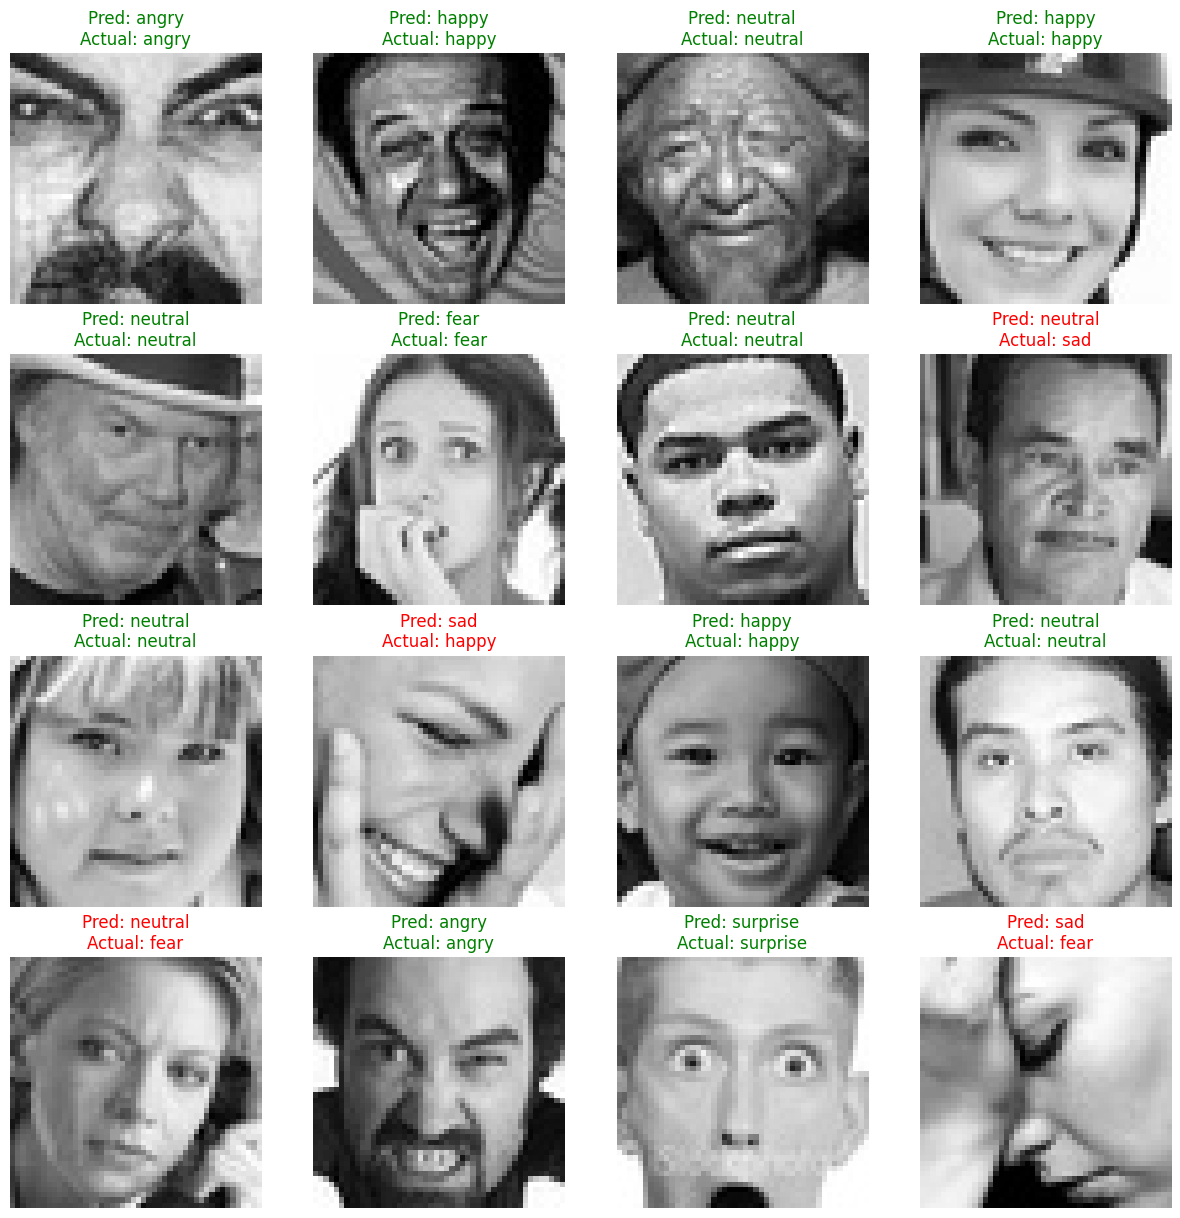

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

test_dir = '/kaggle/input/datasets/msambare/fer2013/test'

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    batch_size=32,
    color_mode="grayscale",
    class_mode='categorical',
    shuffle=True
)

model_path = '/kaggle/working/final_emotion_model.h5'

if 'model' in locals():
    current_model = model
    print("...Using the model currently in memory.")
elif os.path.exists(model_path):
    current_model = load_model(model_path)
    print("Model loaded successfully from the saved file!")
else:
    print("⚠️ Warning: The model is neither in memory nor in the files.")
    print("Please run the training cell (model.fit) first and let it finish.")
    current_model = None

if current_model:
    images, labels = next(test_generator)
    predictions = current_model.predict(images)
    class_labels = list(test_generator.class_indices.keys())

    plt.figure(figsize=(15, 15))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].reshape(48, 48), cmap='gray')
        pred_idx = np.argmax(predictions[i])
        actual_idx = np.argmax(labels[i])
        color = 'green' if pred_idx == actual_idx else 'red'
        plt.title(f"Pred: {class_labels[pred_idx]}\nActual: {class_labels[actual_idx]}", color=color)
        plt.axis('off')
    plt.show()